# E-Commerce Dataset Analysis

## Internship Task - Cognetix Technology

### Using Python, Pandas, Matplotlib and Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ecommerce_data = pd.read_csv(
    "OnlineRetail.csv",
    encoding='latin1'
)

ecommerce_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
ecommerce_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
ecommerce_data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
ecommerce_data = ecommerce_data.drop_duplicates()

ecommerce_data = ecommerce_data.dropna()

ecommerce_data = ecommerce_data[
    ecommerce_data['Quantity'] > 0
]

ecommerce_data = ecommerce_data[
    ecommerce_data['UnitPrice'] > 0
]

ecommerce_data.shape

(392692, 8)

In [7]:
ecommerce_data['Revenue'] = (
    ecommerce_data['Quantity'] *
    ecommerce_data['UnitPrice']
)

ecommerce_data[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [8]:
print(
    "Total Revenue:",
    ecommerce_data['Revenue'].sum()
)

Total Revenue: 8887208.894


In [9]:
top_products = ecommerce_data.groupby(
    'Description'
)['Quantity'].sum().sort_values(
    ascending=False
).head(10)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

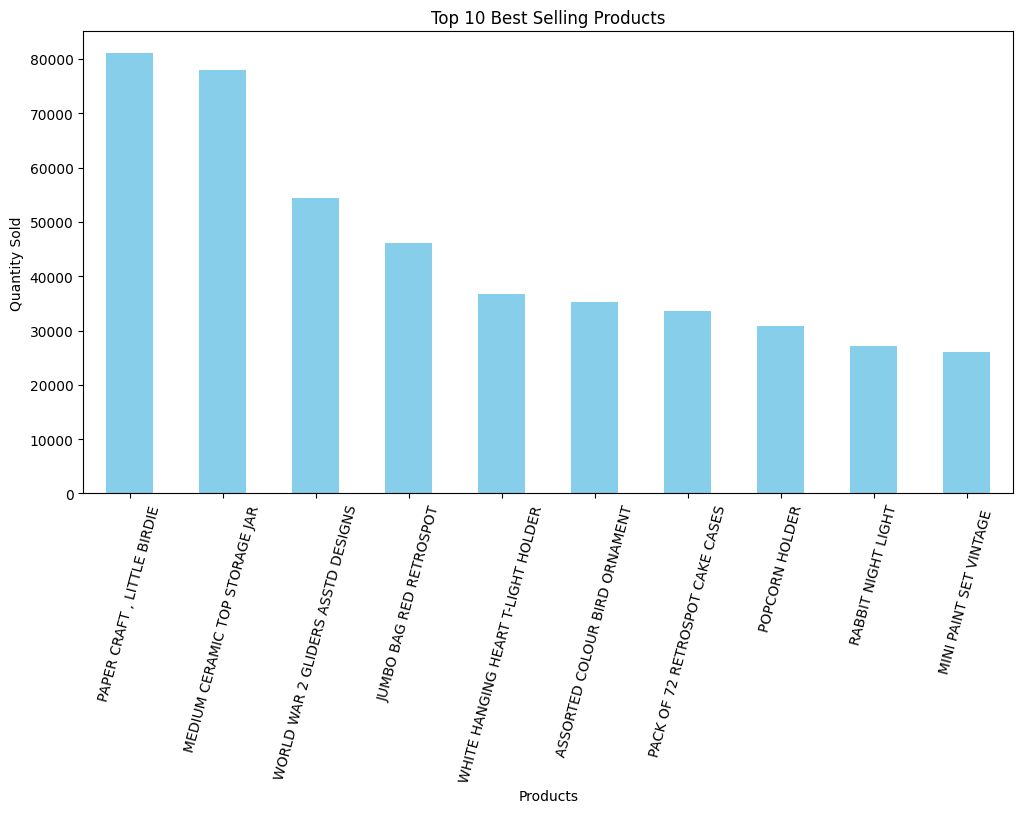

In [10]:
plt.figure(figsize=(12,6))

top_products.plot(
    kind='bar',
    color='skyblue'
)

plt.title('Top 10 Best Selling Products')

plt.xlabel('Products')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=75)

plt.show()

In [11]:
top_revenue = ecommerce_data.groupby(
    'Country'
)['Revenue'].sum().sort_values(
    ascending=False
).head(10)

top_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

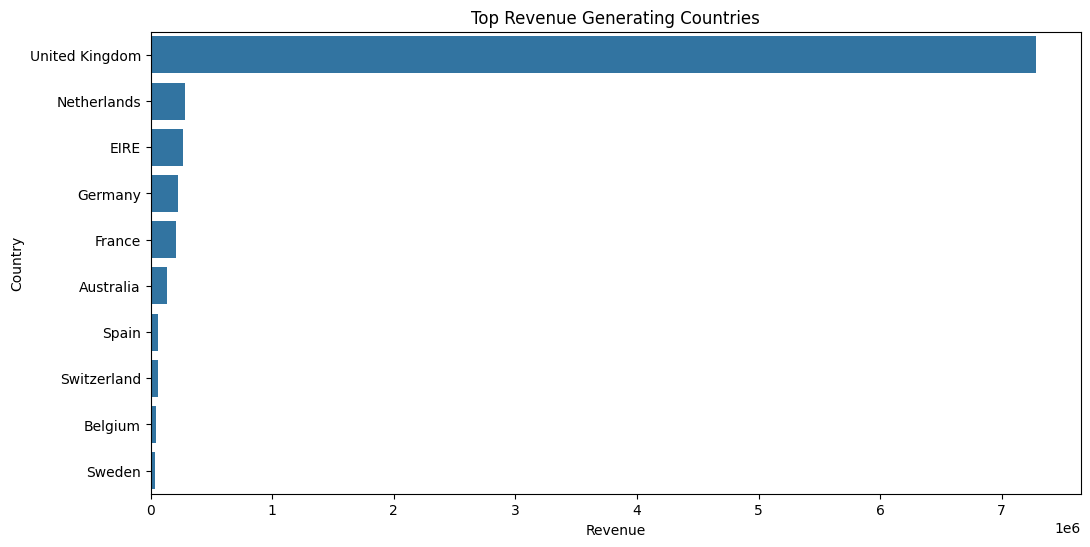

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_revenue.values,
    y=top_revenue.index
)

plt.title('Top Revenue Generating Countries')

plt.xlabel('Revenue')
plt.ylabel('Country')

plt.show()

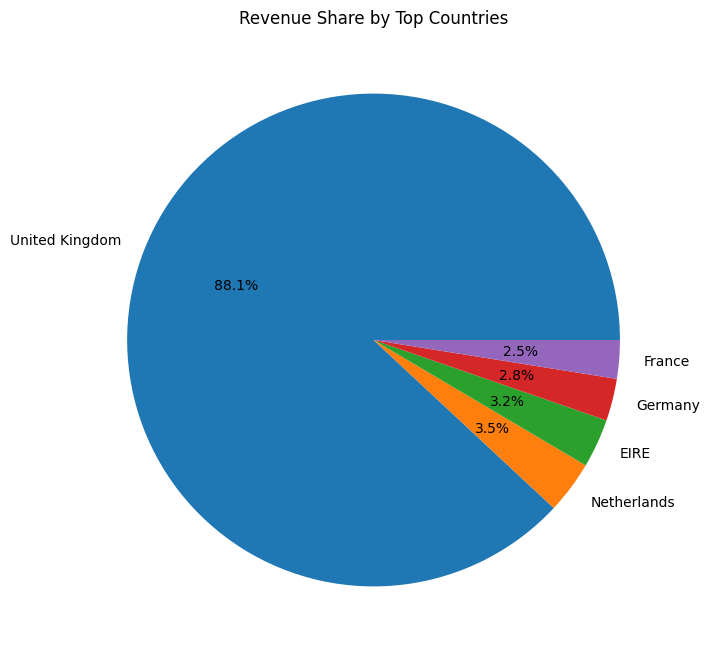

In [13]:
top_revenue.head(5).plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Revenue Share by Top Countries')

plt.ylabel('')

plt.show()

In [14]:
ecommerce_data['InvoiceDate'] = pd.to_datetime(
    ecommerce_data['InvoiceDate']
)

ecommerce_data['Month'] = ecommerce_data[
    'InvoiceDate'
].dt.month

monthly_revenue = ecommerce_data.groupby(
    'Month'
)['Revenue'].sum()

monthly_revenue

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: Revenue, dtype: float64

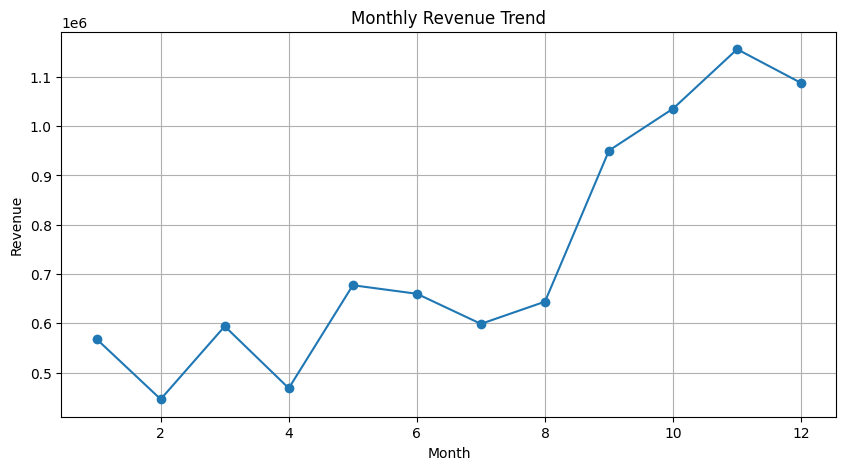

In [15]:
plt.figure(figsize=(10,5))

monthly_revenue.plot(
    marker='o'
)

plt.title('Monthly Revenue Trend')

plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

In [16]:
total_orders = ecommerce_data['InvoiceNo'].nunique()

total_customers = ecommerce_data['CustomerID'].nunique()

print("Total Orders:", total_orders)

print("Total Customers:", total_customers)

Total Orders: 18532
Total Customers: 4338


# Insights

- Certain products generated significantly higher sales volume.
- A few countries contributed the majority of total revenue.
- Revenue trends increased during specific months.
- Customer purchasing activity varied across products and regions.
- Data analysis helped identify top-performing products and markets.

# Conclusion

This project analyzed e-commerce sales data using Python, Pandas, Matplotlib, and Seaborn.

The analysis included:
- Data cleaning
- Revenue analysis
- Product performance analysis
- Country-wise revenue analysis
- Monthly sales trend visualization
- Customer order analysis

The project successfully demonstrated how e-commerce business data can be analyzed to derive meaningful business insights and revenue trends.